# Lineare Regression: Vorhersage des Jahresumsatzes von E-Commerce-Kunden

**Ziel:** Auf Basis von Nutzungsdaten (Zeit auf der Website, Zeit in der App, Mitgliedschaftsdauer etc.) wird der jährliche Umsatz pro Kunde (`Yearly Amount Spent`) mithilfe eines linearen Regressionsmodells vorhergesagt.

**Datensatz:** `data/customers.csv` – Nutzungs- und Umsatzdaten von E-Commerce-Kunden.

**Vorgehen:**
1. Daten laden und auf Qualität prüfen
2. Explorative Datenanalyse (EDA)
3. Modellbildung (lineare Regression)
4. Modellevaluierung
5. Residuenanalyse zur Prüfung der Modellannahmen

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Daten Laden

In [3]:
df_costumer=pd.read_csv("data/customers.csv")

In [9]:
df_costumer.head(2)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933


# Explorative Datenanalyse

Struktur der Daten

In [12]:
df_costumer.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [13]:
df_costumer.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [54]:
df_costumer.duplicated().sum()

np.int64(0)

In [55]:
df_costumer.isna().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Zusammenhänge zwischen Merkmale und Zielgröße

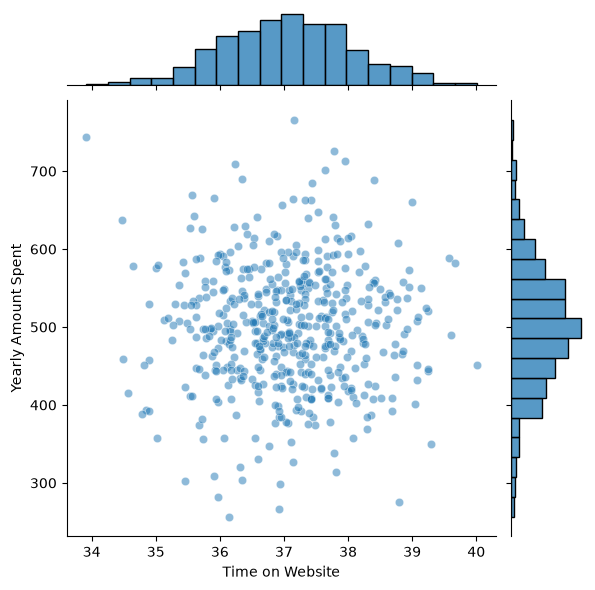

In [ ]:
sns.jointplot(x="Time on Website", y="Yearly Amount Spent", data=df_costumer, alpha=0.5)

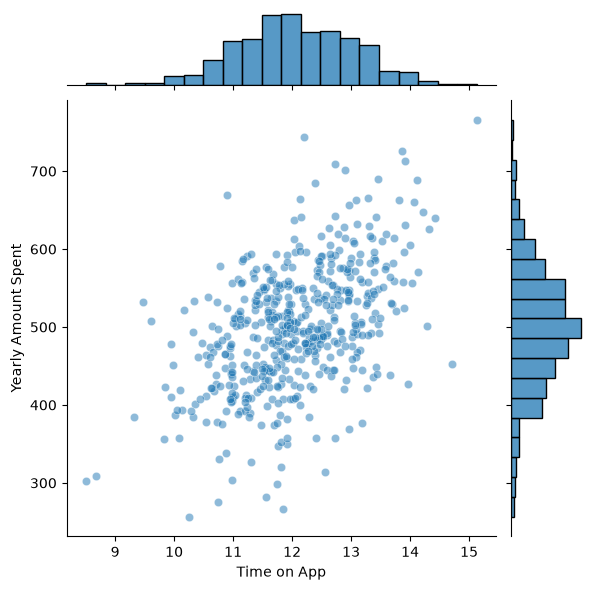

In [16]:
sns.jointplot(x="Time on App", y="Yearly Amount Spent", data=df_costumer, alpha=0.5)

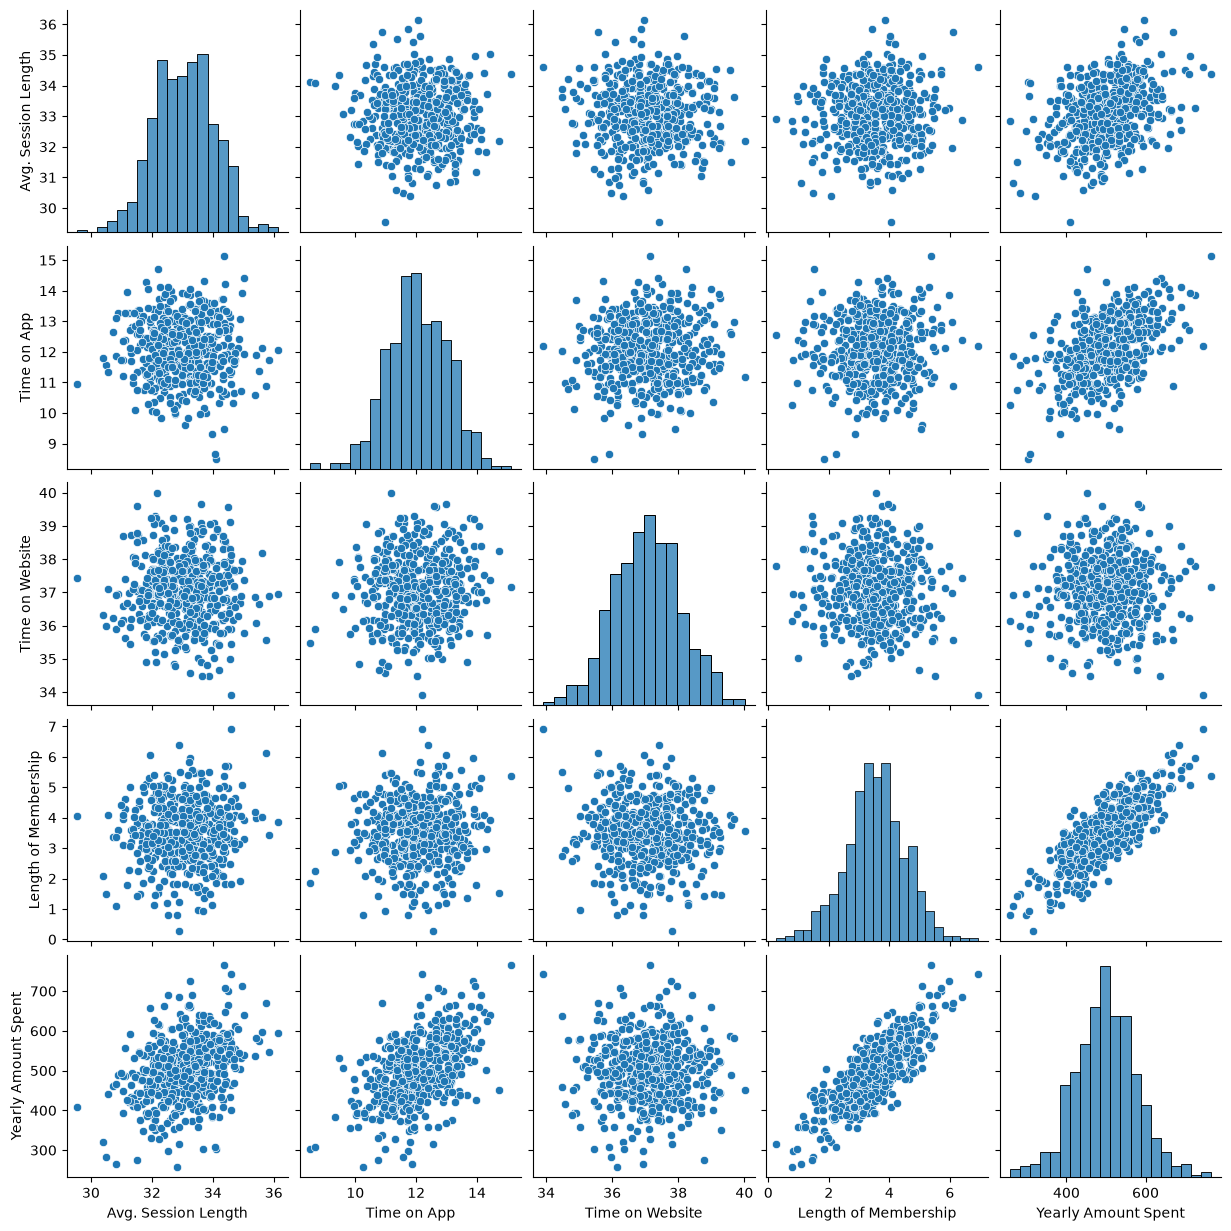

In [17]:
sns.pairplot(df_costumer, kind="scatter")

Length of Membership zeigt deutlich den stärksten linearen Zusammenhang zur Zielvariable

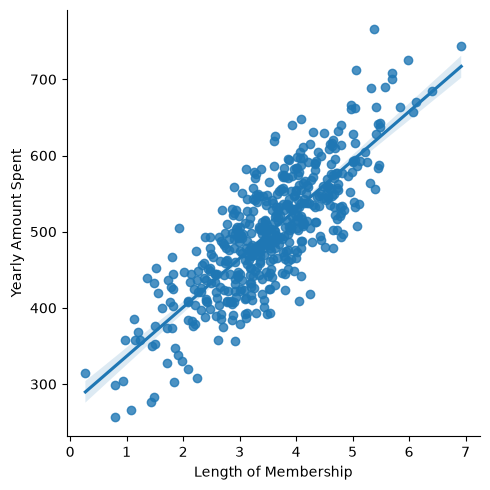

In [18]:
sns.lmplot(x="Length of Membership", y="Yearly Amount Spent", 
data=df_costumer)

# Model building

In [20]:
from sklearn.model_selection import train_test_split

In [25]:
x_temp=df_costumer.select_dtypes(include="number")
x=x_temp.drop(columns="Yearly Amount Spent")
x

,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543
3,34.305557,13.717514,36.721283,3.120179
4,33.330673,12.795189,37.536653,4.446308
...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573
496,34.702529,11.695736,37.190268,3.576526
497,32.646777,11.499409,38.332576,4.958264
498,33.322501,12.391423,36.840086,2.336485


In [26]:
y=df_costumer["Yearly Amount Spent"]
y

0      587.951054
1      392.204933
2      487.547505
3      581.852344
4      599.406092
          ...    
495    573.847438
496    529.049004
497    551.620145
498    456.469510
499    497.778642
Name: Yearly Amount Spent, Length: 500, dtype: float64

In [27]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.3, random_state=42)

In [31]:
print(x_train.size)
print(x_test.size)
print(x.size)
print("---------------")
print(y_train.size)
print(y_test.size)
print(y.size)

1400
600
2000
---------------
350
150
500


In [32]:
# Training the model
from sklearn.linear_model import LinearRegression

In [33]:
lm = LinearRegression()

In [34]:
lm.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[25.72,38.6 , 0.46,61.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Avg. Session Length','Time on App','Time on Website', 'Length of Membership']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1051
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [36]:
lm.coef_

array([25.72425621, 38.59713548,  0.45914788, 61.67473243])

In [37]:
cdf = pd.DataFrame(data=lm.coef_, index=x.columns, columns=['Coef'])
print(cdf)

                           Coef
Avg. Session Length   25.724256
Time on App           38.597135
Time on Website        0.459148
Length of Membership  61.674732


# Evaluierung

In [38]:
# predctions with x_test
prediction=lm.predict(x_test)
prediction

array([403.66993069, 542.57756289, 427.06591658, 502.02460425,
       410.12143559, 569.93442508, 531.93431341, 506.29650969,
       408.71870658, 473.97737105, 441.46912726, 425.33703059,
       425.1297229 , 527.61676714, 431.45684016, 424.0769184 ,
       575.76543296, 484.89856554, 458.35936863, 481.96502182,
       502.32441491, 513.63783554, 507.58877002, 646.57464283,
       450.24372141, 496.27043415, 556.40457807, 554.95630839,
       399.64237199, 325.84623136, 532.89783259, 478.12238702,
       501.05701845, 305.97335848, 505.77244448, 483.79591969,
       518.8331528 , 438.18241857, 456.71094234, 471.04609461,
       494.44008972, 445.31155755, 508.78802753, 501.04594193,
       488.83499673, 535.38079541, 595.20129802, 514.04714872,
       280.76758312, 433.10112367, 421.70823427, 481.23640152,
       584.71372272, 608.7748096 , 563.98513427, 494.72804869,
       394.52133407, 456.4197529 , 573.08767515, 499.6984241 ,
       512.83277025, 392.12434043, 480.05057697, 481.54

Text(0.5, 1.0, 'Evaluation of pur LM model')

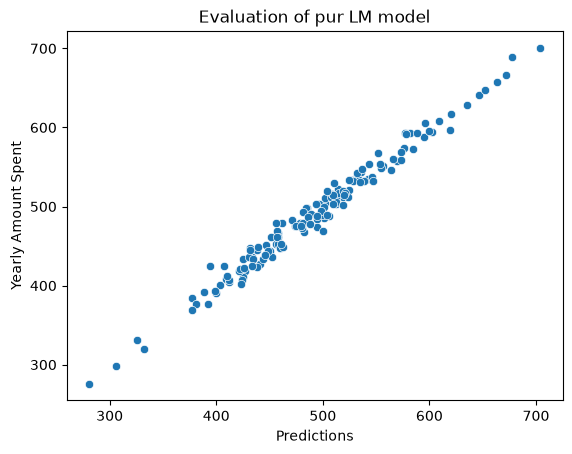

In [40]:
sns.scatterplot(x=prediction, y=y_test)
plt.xlabel("Predictions")
plt.title("Evaluation of pur LM model")

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [44]:
print("Mean Absolute Error ", mean_absolute_error(y_test, prediction))
print("Mean Squared Error ", mean_squared_error(y_test, prediction))
print("Root Mean Squared Error ", math.sqrt(mean_squared_error(y_test, prediction)))

Mean Absolute Error  8.426091641432116
Mean Squared Error  103.91554136503333
Root Mean Squared Error  10.193897260863155


# Residual Analysis

In [ ]:
# Residuenanalyse
residuals= y_test - prediction

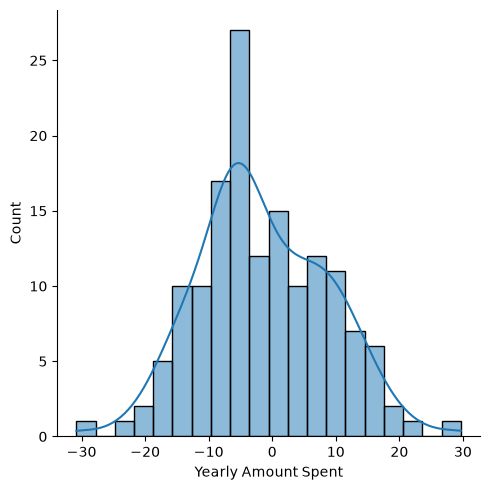

In [49]:
sns.displot(residuals, bins=20, kde=True)

In [50]:
import pylab

In [51]:
import scipy.stats as stats

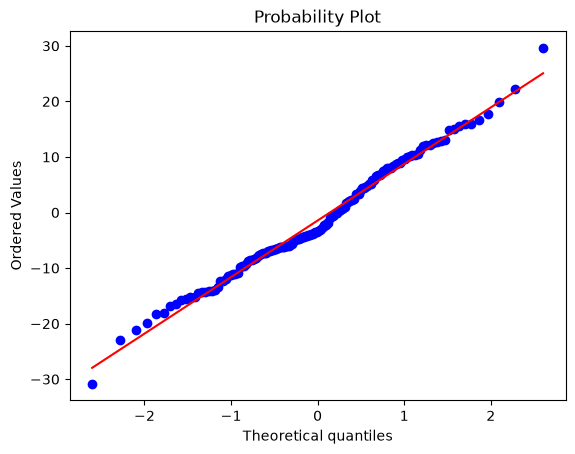

In [52]:
stats.probplot(residuals, dist="norm", plot=pylab)
pylab.show()

# Fazit

Den größsten Einfluss auf den Umsatz hat laut Modellkoeffizient das Merkmal Length of Membership (61.674732). Ein zusätzlicher Anstieg dieses Merkmals um eine Einheit ist im Modell mit einer Umsatzsteigerung von rund 61 assoziert, bei sonst gleichbleibenden Bedingungen.
Die Residuenanalyse zeigt eine annäherend normalverteilte Verteilung der Fehler, was auf eine gültige Modellannahme hindeutet.
Insgesamt eignet sich das Modell gut für eine erste Umsatzabschätzung, sollte für den produktiven Einsatz aber durch Vergleichsmodelle (z. B. Ridge, Random Forest) und Cross-Validation abgesichert werden.